# Differential Expression Analysis for CCC & Downstream Signalling Networks

## Background

Cell-cell communication (CCC) events play a critical role in diseases, often experiencing deregulation. To identify differential expression of CCC events between conditions, we can build upon standard differential expression analysis (DEA) approaches, such as [DESeq2](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-014-0550-8?ref=https://githubhelp.com). While dimensionality reduction methods like extracting intercellular programmes with [MOFA+](https://liana-py.readthedocs.io/en/latest/notebooks/mofatalk.html) and [Tensor-cell2cell](https://liana-py.readthedocs.io/en/latest/notebooks/liana_c2c.html) reduce CCC into sets of loadings, hypothesis-driven DEA tests focus on individual gene changes, making them easier to understand and interpret.

In this tutorial, we perform DEA at the pseudobulk level to assess differential expression of genes between conditions. We then translate the results into deregulated complex-informed ligand-receptor interactions and analyze their connections to downstream signaling events.

For further information on pseudobulk DEA, please refer to the [Differential Gene Expression chapter](https://www.sc-best-practices.org/conditions/differential_gene_expression.html) in the Single-cell Best Practices book, as well as [Decoupler's pseudobulk vignette](https://decoupler-py.readthedocs.io/en/latest/notebooks/pseudobulk.html). These resources provide more comprehensive details on the subject.


## Load Packages

In [ ]:
from tqdm import tqdm
import pickle
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path

import plotnine as p9

import liana as li
import decoupler as dc
import omnipath as op

# Import DESeq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

DATADIR = Path("../../../../data") / "processed" / "external"

In [4]:
# utily function to select top n interactions
def select_top_n(d, n=None):
    d = dict(sorted(d.items(), key=lambda item: abs(item[1]), reverse=True))
    return {k: v for i, (k, v) in enumerate(d.items()) if i < n}

# Obtain TF regulons
net = dc.op.collectri(organism='mouse', remove_complexes=False, license='academic', verbose=False)

## Load & Prep Data

As a simple example, we will look at ~25k PBMCs from 8 pooled patient lupus samples, each before and after IFN-beta stimulation ([Kang et al., 2018](https://www.nature.com/articles/nbt.4042); [GSE96583](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE96583)). Note that by focusing on PBMCs, for the purpose of this tutorial, we assume that coordinated events occur among them.

This dataset is downloaded from a link on Figshare; preprocessed for [pertpy](https://github.com/theislab/pertpy).

Define columns of interest from `.obs`

Note that we use cell abbreviations because MOFA will use them as labels for the views.

In [4]:
adata = sc.read_h5ad(DATADIR / "analyzed.h5ad")
sample_key = 'sample'
groupby = 'celltype'
condition_key = 'timepoint'
batch_key = 'batch'
celltypes_focus = ['Neu Phox2b+', 'Airway neurons']

adata

AnnData object with n_obs × n_vars = 36344 × 19059
    obs: 'batch', 'nCount_RNA', 'nFeature_RNA', 'number_clusters', 'percent.mt', 'log10_nCount_RNA', 'log10_nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'seurat_clusters', 'x', 'y', 'celltype', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.30', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.40', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.50', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.60', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.70', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.80', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.90', 'BANKSY_labels_nonspatial_pc30_nc0.00_r1.00', 'BANKSY_labels_scaled_gaussian_pc30_nc0.20_r0.30', 'BANKSY_labels_scaled_ga

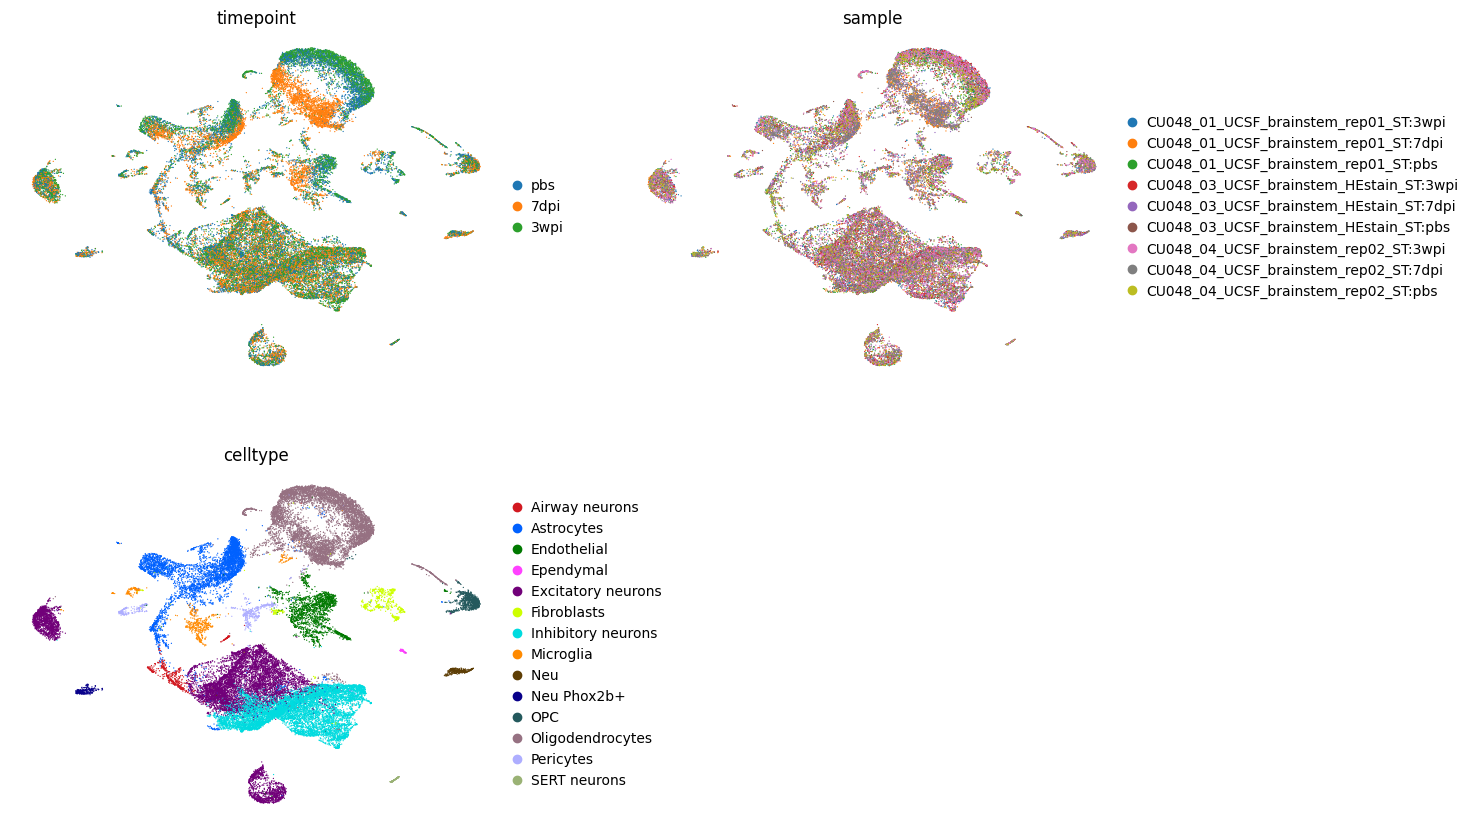

View of AnnData object with n_obs × n_vars = 36269 × 19059
    obs: 'batch', 'nCount_RNA', 'nFeature_RNA', 'number_clusters', 'percent.mt', 'log10_nCount_RNA', 'log10_nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'seurat_clusters', 'x', 'y', 'celltype', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.30', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.40', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.50', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.60', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.70', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.80', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.90', 'BANKSY_labels_nonspatial_pc30_nc0.00_r1.00', 'BANKSY_labels_scaled_gaussian_pc30_nc0.20_r0.30', 'BANKSY_labels_s

In [5]:
# Show pre-computed UMAP
sc.pl.embedding(adata, "UMAP_SCT", color=[condition_key, sample_key, groupby], frameon=False, ncols=2)
pd.crosstab(adata.obs["celltype"], adata.obs["sample"])

# Remove ependymal cells
adata = adata[~adata.obs["celltype"].isin(["Ependymal"])]
adata

## Differential Testing

First, we need to generate pseudobulk profiles for each cell type, and we do so using the [`decoupler` package](https://decoupler-py.readthedocs.io/en/latest/notebooks/pseudobulk.html). 

Installed version: v0.9.1-alpha.6 (latest: v0.0.0)
Available backends: CVXPY v1.8.1
Default backend (corneto.K): CVXPY
Installed solvers: CBC, CLARABEL, GUROBI, HIGHS, OSQP, SCIP, SCIPY, SCS
Graphviz version: Graphviz not installed. To support plotting, please install graphviz with conda
Repository: https://github.com/saezlab/corneto


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

                                                    psbulk_cells  \
CU048_01_UCSF_brainstem_rep01_ST:3wpi_SERT neurons          10.0   
CU048_03_UCSF_brainstem_HEstain_ST:pbs_SERT neu...          10.0   
CU048_04_UCSF_brainstem_rep02_ST:3wpi_Neu Phox2b+           10.0   
CU048_03_UCSF_brainstem_HEstain_ST:3wpi_Neu Pho...          15.0   
CU048_03_UCSF_brainstem_HEstain_ST:3wpi_SERT ne...          15.0   
...                                                          ...   
CU048_04_UCSF_brainstem_rep02_ST:7dpi_Excitator...        1144.0   
CU048_04_UCSF_brainstem_rep02_ST:3wpi_Excitator...        1163.0   
CU048_04_UCSF_brainstem_rep02_ST:7dpi_Inhibitor...        1178.0   
CU048_03_UCSF_brainstem_HEstain_ST:3wpi_Excitat...        1270.0   
CU048_04_UCSF_brainstem_rep02_ST:3wpi_Inhibitor...        1310.0   

                                                    psbulk_counts  
CU048_01_UCSF_brainstem_rep01_ST:3wpi_SERT neurons        85764.0  
CU048_03_UCSF_brainstem_HEstain_ST:pbs_SERT neu

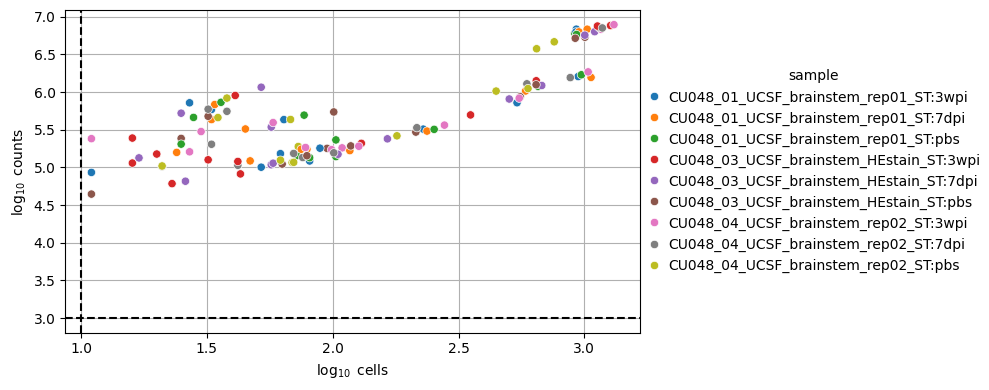

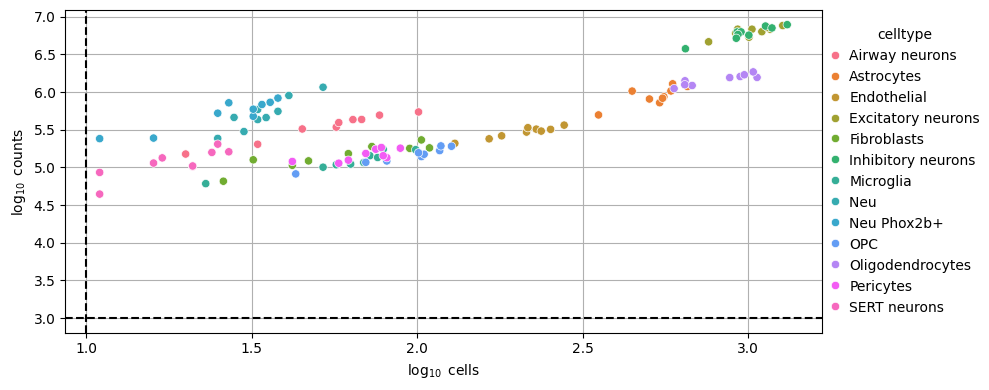

In [ ]:
pdata = dc.pp.pseudobulk(
    adata,
    sample_col=sample_key,
    groups_col=groupby,
    layer='counts',
    mode='sum'
)
print(pdata.obs[["psbulk_cells", "psbulk_counts"]].sort_values("psbulk_cells"))

# filter samples based on number of cells and counts
dc.pp.filter_samples(pdata, min_cells = 10, min_counts=1000)

for col in [sample_key, groupby]:
    dc.pl.filter_samples(pdata, groupby=col, figsize=(10, 4))

We can plot the quality control metrics for each pseudobulk sample:

#### Differential Expression Analysis

Next, now that we have generated the pseudobulk profiles, we can perform some edgeR-like filtering using decoupler-py, and then differential expression analysis using the [`pydeseq2` package](https://pydeseq2.readthedocs.io/en/latest/) - a re-implementation of the original DESeq2 method ([Love et al., 2014](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-014-0550-8?ref=https://githubhelp.com)).

Here, we perform DEA on the pseudobulk profiles for each cell type, for more info check this tutorial:
https://decoupler-py.readthedocs.io/en/latest/notebooks/pseudobulk.html

In [7]:
# %%capture

dea_results = {}
comparison = [condition_key, 'pbs', '7dpi']
quiet = True

for cell_group in tqdm(pdata.obs[groupby].unique()):
    # Select cell profiles
    ctdata = pdata[pdata.obs[groupby] == cell_group].copy()

    # Obtain genes that pass the edgeR-like thresholds
    # NOTE: QC thresholds might differ between cell types, consider applying them by cell type
    genes = dc.pp.filter_by_expr(
        ctdata,
        group=condition_key,
        min_count=5, # a minimum number of counts in a number of samples
        min_total_count=10, # a minimum total number of reads across samples
        inplace=False)

    # Filter by these genes
    ctdata = ctdata[:, genes].copy()
    
    # Build DESeq2 object
    # NOTE: this data is actually paired, so one could consider fitting the patient label as a confounder
    dds = DeseqDataSet(
        adata=ctdata,
        design=f'~{condition_key}+{batch_key}',
        refit_cooks=True,
        quiet=quiet,
        n_cpus = 10
    )
    
    # Compute LFCs
    dds.deseq2()
    # Contrast between stim and ctrl
    stat_res = DeseqStats(dds, contrast=comparison, quiet=quiet)
    stat_res.quiet = quiet
    # Compute Wald test
    stat_res.summary()
    # Shrink LFCs
    stat_res.lfc_shrink(coeff='timepoint[T.7dpi]') # {condition_key}_cond_vs_ref
    
    dea_results[cell_group] = stat_res.results_df

 46%|████▌     | 6/13 [02:49<03:30, 30.03s/it]/mnt/DATA/home/ethung/spatial_seq/.pixi/envs/main/lib/python3.14/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/mnt/DATA/home/ethung/spatial_seq/.pixi/envs/main/lib/python3.14/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/mnt/DATA/home/ethung/spatial_seq/.pixi/envs/main/lib/python3.14/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/mnt/DATA/home/ethung/spatial_seq/.pixi/envs/main/lib/python3.14/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/mnt/DATA/home/ethung/spatial_seq/.pixi/envs/main/lib/python3.14/site-packages/pydeseq2/utils.py:1088:

<div class="alert alert-info">

This results in a wall of currently unavoidable verbose text and prints, as such I use `%%capture` to hide it.
One can use ``quiet`` to some of the functions but not logfc_shrinkage

</div>  


In [8]:
# concat results across cell types
dea_df = pd.concat(dea_results)
dea_df = dea_df.reset_index().rename(columns={'level_0': groupby,'level_1':'index'}).set_index('index')

# PyDeseq Seems to intrdoce NAs for some p-values
# NOTE: there sometimes some NaN being introduced, best to double check that, in this case it's only for a single gene, but it might be a problem.
print("NaNs introduced:", len(dea_df[dea_df.isna().any(axis=1)]))

dea_df.head()

NaNs introduced: 44570


,celltype,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
index,,,,,,,
Xkr4,Airway neurons,22.167803,0.000706,0.103581,0.368109,0.712792,0.999304
Lypla1,Airway neurons,15.311559,-0.001453,0.104157,-0.633596,0.526345,0.999304
Tcea1,Airway neurons,40.887999,-0.012904,0.100803,0.525591,0.599173,0.999304
Rgs20,Airway neurons,7.260624,0.015585,0.112466,-0.284350,0.776142,NaN
Atp6v1h,Airway neurons,92.085311,-0.004253,0.094389,0.788537,0.430383,0.999304


## DEA to Ligand-Receptor Interactions

Now that we have DEA results per gene, we can combine them into statistics of potentially deregulated ligand-receptor interactions.

To do so, liana provides a simple function `li.multi.df_to_lr` that calculates average expression as well as proportions based on the passed `adata` object, and combines those with the DEA results and a ligand-receptor resource. Since in this case we want to focus on gene statics relevant to the condition (stim), let's subset the adata to those and normalize the counts.

In [9]:
celltypes_focus = ['Neu Phox2b+', 'Airway neurons']
adata_7dpi = adata[adata.obs[condition_key] == '7dpi'].copy()
adata_7dpi.X = adata_7dpi.layers["counts"]

In [10]:
sc.pp.normalize_total(adata_7dpi, target_sum=1e4)
sc.pp.log1p(adata_7dpi)

Let's combine the DEA results with the ligand-receptor interactions. We need to pass the names of the statistics from the DEA table in which we are interest to `li.multi.df_to_lr`, here we will use the adjusted p-values and Wald test statistic.

In [11]:
lr_res = li.multi.df_to_lr(adata_7dpi,
                           dea_df=dea_df,
                           resource_name='mouseconsensus',
                           expr_prop=0.1,
                           groupby=groupby,
                           stat_keys=['stat', 'pvalue', 'padj'],
                           use_raw=False,
                           complex_col='stat', # NOTE: we use the Wald Stat to deal with complexes
                           verbose=True,
                           return_all_lrs=False,
                           )

lr_res = lr_res.sort_values("interaction_stat", ascending=False, key=abs)
lr_res.head()

Using resource `mouseconsensus`.
Using `.X`!
2483 features of mat are empty, they will be removed.
/mnt/DATA/home/ethung/spatial_seq/.pixi/envs/main/lib/python3.14/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
Features in adata and dea_df are mismatched.
0.28 of entities in the resource are missing from the data.


,ligand,receptor,ligand_complex,receptor_complex,source,ligand_stat,ligand_pvalue,ligand_padj,ligand_expr,ligand_props,...,receptor_pvalue,receptor_padj,receptor_expr,receptor_props,interaction_stat,interaction_pvalue,interaction_padj,interaction_expr,interaction_props,interaction
43780,Apoe,Abca1,Apoe,Abca1,Oligodendrocytes,-13.944329,3.406379e-44,1.792566e-41,2.449101,0.766437,...,7.901304e-13,5.633375e-11,0.396363,0.183486,-10.553593,3.950652e-13,2.816688e-11,1.422732,0.474962,Apoe^Abca1
43402,Apod,Lepr,Apod,Lepr,Oligodendrocytes,-20.234118,4.903230e-91,9.030932e-88,4.217514,0.915902,...,6.486185e-01,NaN,0.077737,0.181818,-9.889218,3.243092e-01,9.030932e-88,2.147625,0.548860,Apod^Lepr
43195,Trf,Ldlr,Trf,Ldlr,Oligodendrocytes,17.948556,4.925451e-72,6.047907e-69,2.623308,0.846713,...,1.179715e-01,4.747520e-01,0.573354,0.633333,9.755950,5.898573e-02,2.373760e-01,1.598331,0.740023,Trf^Ldlr
42618,Apod,Lepr,Apod,Lepr,Oligodendrocytes,-20.234118,4.903230e-91,9.030932e-88,4.217514,0.915902,...,4.497774e-01,8.564601e-01,0.478972,0.223214,-9.739166,2.248887e-01,4.282300e-01,2.348243,0.569558,Apod^Lepr
44062,Trf,Ldlr,Trf,Ldlr,Oligodendrocytes,17.948556,4.925451e-72,6.047907e-69,2.623308,0.846713,...,2.517848e-01,NaN,0.349133,0.338983,9.547290,1.258924e-01,6.047907e-69,1.486220,0.592848,Trf^Ldlr



##### Dealing with heteromeric complexes

LIANA will filter lowly-expressed interactions, i.e. those for which any of the genes are not expressed in at least **0.1** of the cells (by default) in the AnnData object. This can be adjusted with the `expr_prop` parameter. 

Moreover, to deal with complexes for each cell type, as either source or target of the potential CCC events, LIANA will find and assign the subunit of a complex with the lowest gene expression (by default) as the subunit of interest, and will then use the stats for that subunit as the stats of the whole protein complex.

<div class="alert alert-info">
This is a simple heuristic also adapted by many other methods, but it is not perfect, as in some cases it might be over-conservative. For example, if the subunit with lowest expression is not the one that is differentially expressed, the complex will not be detected as deregulated.

To this end, we also provide the option to provide a `complex_col` parameter, which will be used to assign the complex subunit of interest. This column should be a part of the `stat_keys`. Note that the **absolute minimum value** is used (i.e. the value closest to 0 is thought to be the 'worst' result), so this will not work for statistics with ascending values (e.g. p-values).
</div>  

## Visualize the Results

<div class="alert alert-success">

`interaction_*` columns returned by `li.multi.dea_to_lr` are just the mean of the ligand and receptor columns of the corresponding statistic!
Please use with caution as this is just a summary of the interaction that we can use to e.g. to sort the interactions as done above.
Instead, we recommend to use the ligand and receptor statistics **separately** to filter and visualize the interactions.

</div>

Moreover, by averaging the statistics across the ligand and receptor, we  are focusing on the interactions for which both the ligand and receptor are deregulated in the same direction, i.e. both up or both down. However, this might ignore interactions in which e.g. the the ligand is deregulated while the receptor is not, or such where they are deregulated in opposite directions. These could represent potential inhibitory mechanisms, but we leave this to the user to explore.



<Axes: >

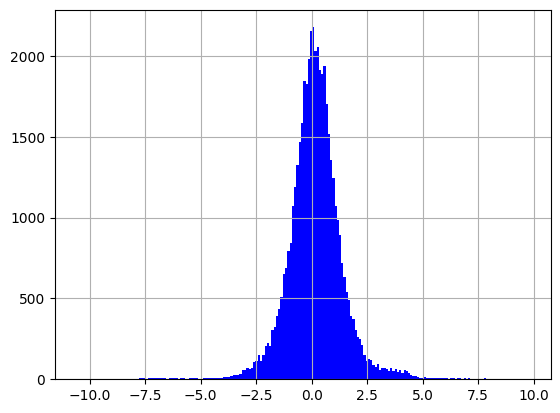

In [12]:
# Let's visualize how this looks like for all interactions  (across all cell types)
lr_res = lr_res.sort_values("interaction_stat", ascending=False)
import matplotlib.pyplot as plt
f,ax = plt.subplots(1,1)
lr_res["interaction_stat"][:32767].hist(bins=100, ax=ax, color="blue")
lr_res["interaction_stat"][32767:].hist(bins=100, ax=ax, color="blue")

Now that we have covered the basics, we can visualize our interactions in a few ways. 

Let's start with the top interactions according to their Wald statistic, and then plot the statistics for the ligands & receptors involved in those interactions across cell types, to do so LIANA+ provide `li.pl.tileplot`:

/mnt/DATA/home/ethung/spatial_seq/.pixi/envs/main/lib/python3.14/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/mnt/DATA/home/ethung/spatial_seq/.pixi/envs/main/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_text : Removed 1510 rows containing missing values.


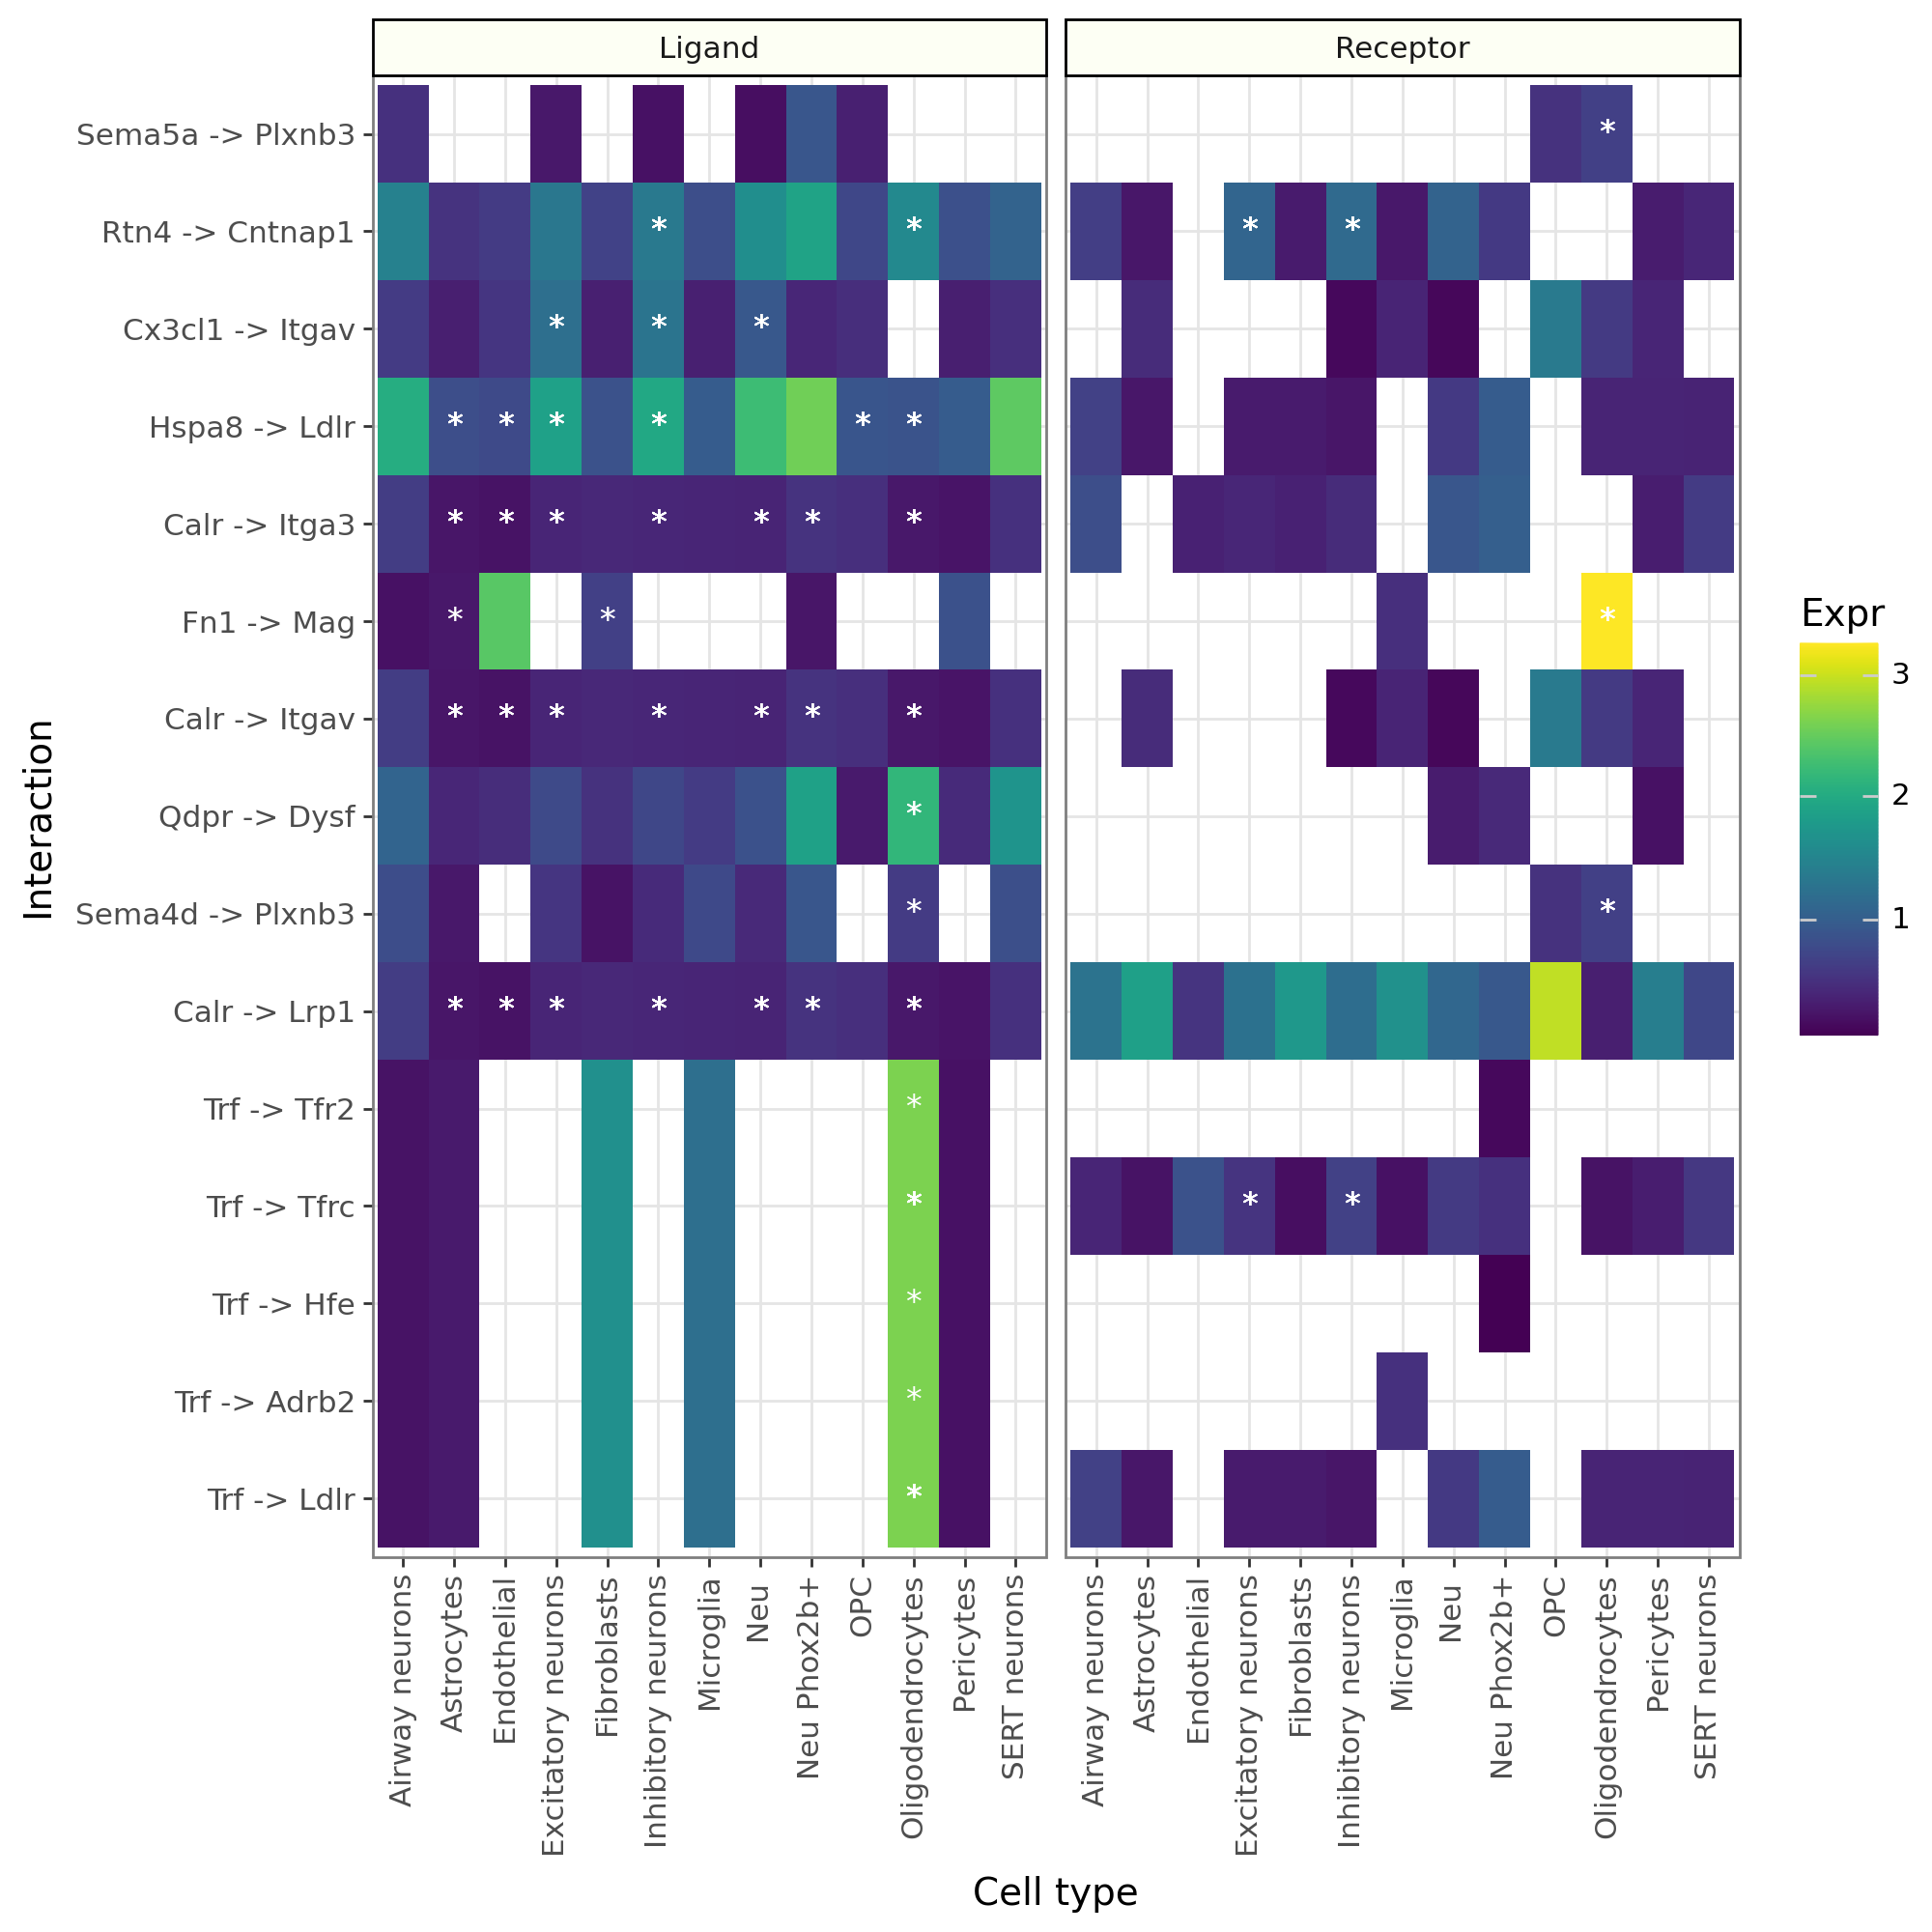

In [13]:
li.pl.tileplot(
    liana_res=lr_res,
    fill = 'expr',
    label='padj',
    label_fun = lambda x: '*' if x < 0.05 else np.nan,
    top_n=15,
    orderby = 'interaction_stat',
    orderby_ascending = False,
    orderby_absolute = False,
    source_title='Ligand',
    target_title='Receptor',
    figure_size=(10,10),
)

If you want to plot the expression values for ligand-receptor interactions without the DEA statistics, you can set the `return_all_lrs` parameter to `True` in the `li.multi.dea_to_lr` function. This will return a dataframe with all the ligand-receptor interactions, where missing DEA stats will be set as `nan`, while mean expression and proportions per cluster will be obtained via the AnnData object.

### Ligand-Receptor Plot

We can also use visualize of the stats, summarized at the level of the interaction, to prioritize the interactions, or any subunit statistics using `li.pl.dotplot`. For example, we can visualize the mean Wald statistic between the ligand & receptor, together with the pvalues for the ligand.

/mnt/DATA/home/ethung/spatial_seq/.pixi/envs/main/lib/python3.14/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/mnt/DATA/home/ethung/spatial_seq/.pixi/envs/main/lib/python3.14/site-packages/plotnine/scales/scales.py:48: PlotnineWarning: Scale for 'color' is already present.
Adding another scale for 'color',
which will replace the existing scale.



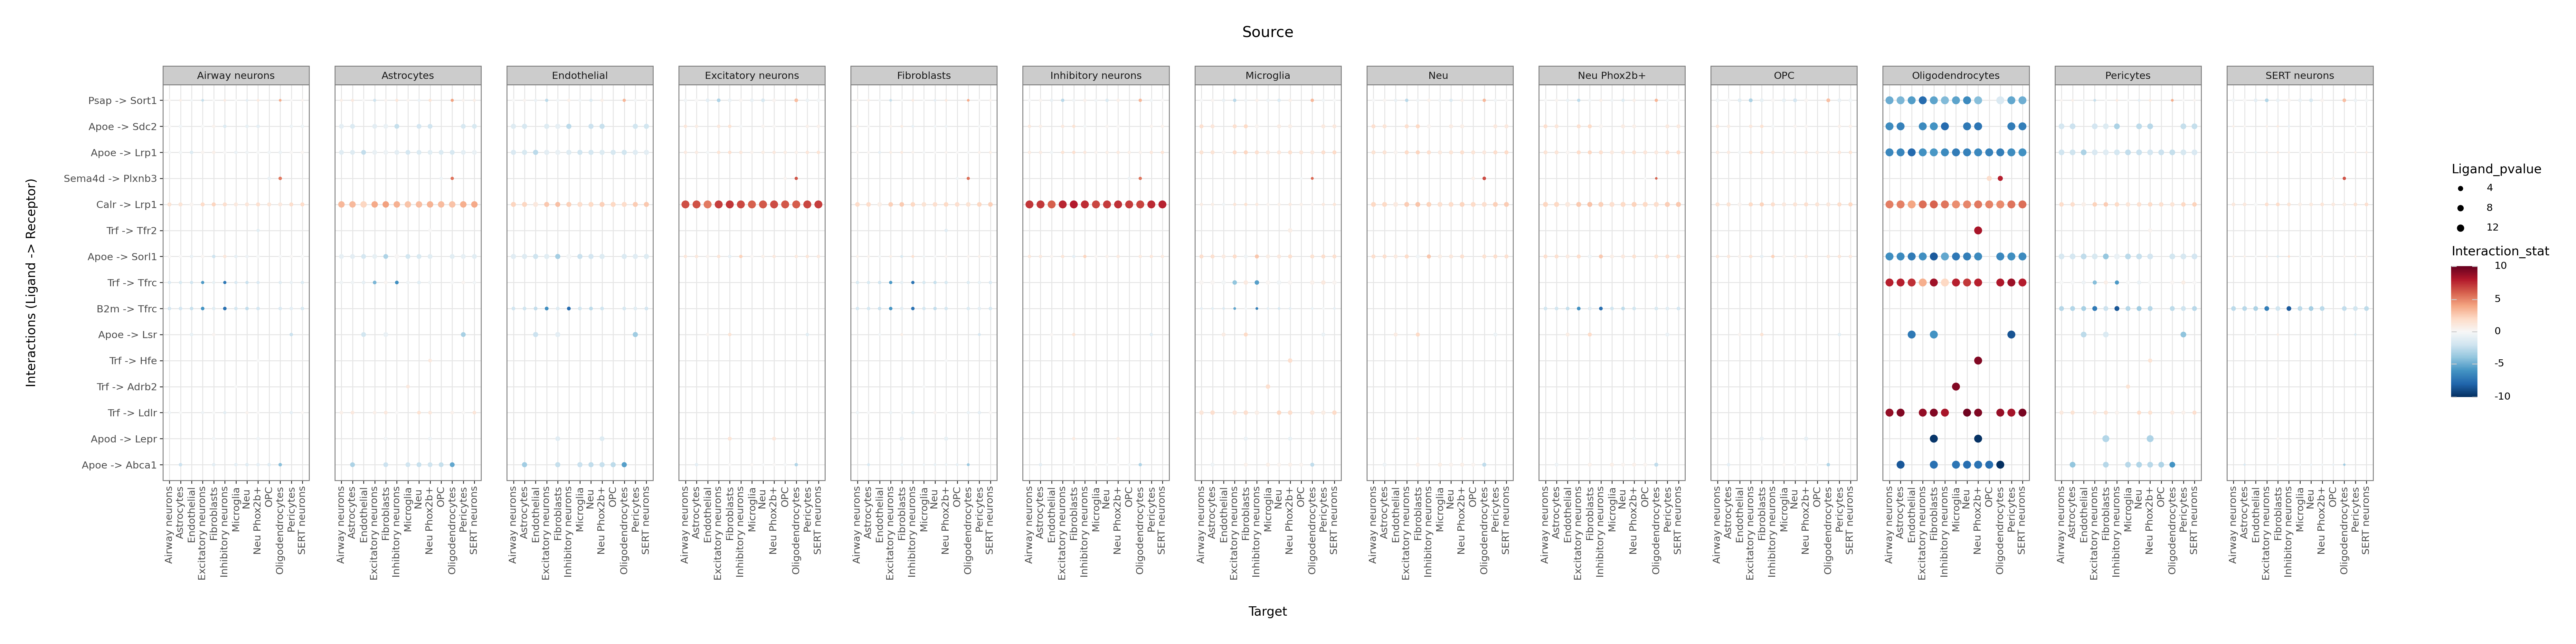

In [14]:
p9.options.limitsize = False

plot = li.pl.dotplot(liana_res=lr_res,
                     colour='interaction_stat',
                     size='ligand_pvalue',
                     inverse_size=True,
                     orderby='interaction_stat',
                     orderby_ascending=False,
                     orderby_absolute=True,
                     top_n=15,
                     size_range=(0.5, 4),
                     )

# customize plot
(
    plot
    + p9.theme_bw(base_size=14)
    # fill cmap blue to red, with 0 the middle
    + p9.scale_color_cmap('RdBu_r', limits=(-10, 10))
    # rotate x
    + p9.theme(axis_text_x=p9.element_text(angle=90), figure_size=(40, 10))

)

Now that we have identified a set of interactions that are potentially deregulated we can look into the downstream signalling events that they might be involved in.

<div class="alert alert-info">
  One can also estimate ligand-receptor pathway activities, etc, these are covered multiple times in other tutorials, but also are applicable here.
</div>

## Intracellular Signaling Networks

Cellular signaling networks govern the behavior of cells, allowing them to respond to external signals, including various cell-cell communication events. Thus, CCC events can be thought of as upstream perturbants of intracellular signaling networks that lead to deregulations of downstream signaling events. Such deregulations are expected to be associated with various conditions and disease. Thus, understanding intracellular signaling networks is critical to model the cellular mechanisms.

Here, we will combine several tools to identify plausible signalling cascades driven by CCC events.

Our approach includes the following steps:

* Select a number of potentially deregulated ligand-receptor interactions (input nodes), in terms of summarized PyDESeq2 statistics.

* Select a number of potentially deregulated TFs (output nodes). This is done via the use of Transcription factor (TF) activity inference. Carried out on differential gene expression data using [TF regulon knowledge](https://github.com/saezlab/CollecTRI) with [decoupler](https://github.com/saezlab/decoupler-py)

* Obtain a prior knowledge network (PKNs), with signed protein-protein interactions from OmniPath.

* Generate weights for the nodes in the PKN

* Use CORNETO to identify a solution in the form of a [causal (smallest sign-consistent signaling) network](https://www.nature.com/articles/s41540-019-0118-z) that explains the measured inputs and outputs

<img src="causal-networks.png" width=800 />




### Select Receptors of interest filtered by Celltype of interest

One limitation of using DEA to identify interactions of interest is that it tells us little about deregulation at the level of cell types.
However, from dimensionality reductions on CCC, as done with [Tensor-cell2cell](https://liana-py.readthedocs.io/en/latest/notebooks/liana_c2c.html) & [MOFA](https://liana-py.readthedocs.io/en/latest/notebooks/mofatalk.html#) on the same dataset, we can see there is a potential deregulation of CCC that involve CD14 monocytes both as sources (senders) and targets (or receivers) of intecellular communication. Thus, we will focus on the interactions and downstream signalling within that cell type.

In [28]:
N = 500

target = [celltypes_focus[0]]

# NOTE: We sort by the absolute value of the interaction stat
lr_stats = lr_res[lr_res['target'].isin(target)].copy()
lr_stats = lr_stats.sort_values('interaction_stat', ascending=False, key=abs)
print(lr_stats.head(10))

input_scores = lr_stats.head(1000).set_index('receptor')['interaction_stat'].to_dict()
print(len(input_scores))

      ligand receptor ligand_complex receptor_complex              source  \
43402   Apod     Lepr           Apod             Lepr    Oligodendrocytes   
43399    Trf     Ldlr            Trf             Ldlr    Oligodendrocytes   
43519    Trf      Hfe            Trf              Hfe    Oligodendrocytes   
43401    Trf     Tfr2            Trf             Tfr2    Oligodendrocytes   
43400    Trf     Tfrc            Trf             Tfrc    Oligodendrocytes   
6438     Agt   Adra2a            Agt           Adra2a          Astrocytes   
43498   Apoe    Abca1           Apoe            Abca1    Oligodendrocytes   
43395   Apoe     Sdc2           Apoe             Sdc2    Oligodendrocytes   
23865   Calr     Lrp1           Calr             Lrp1  Inhibitory neurons   
43397   Apoe     Lrp8           Apoe             Lrp8    Oligodendrocytes   

       ligand_stat  ligand_pvalue   ligand_padj  ligand_expr  ligand_props  \
43402   -20.234118   4.903230e-91  9.030932e-88     4.217514      0.915902

### Select Transcription Factors of interest

Before we select the transcription factors, we need to infer their activity. We will do so using [decoupler](https://github.com/saezlab/decoupler-py) with [CollecTri](https://github.com/saezlab/CollecTRI) regulons. Specifically, we will estimate TF activities using the Wald statistics (from PyDESeq2) for the genes in the regulons.

In [ ]:
N = 10

# Pull all DEG stats
tmp = dea_df.reset_index(names="gene")
dea_wide = tmp.pivot(columns=groupby, index='gene', values='stat').T
dea_wide.columns = tmp.sort_values("gene")['gene'].unique()
dea_wide = dea_wide.fillna(0)
dea_wide

# Run Enrichment Analysis on top TFs
estimates, pvals = dc.mt.ulm(dea_wide, net=net)
estimates.T.sort_values(target, key=abs, ascending=False).head()

# Select top TFs
tf_data = estimates.copy()
tf_dict = tf_data.loc[target].reset_index(drop=True).T.to_dict()[0]
output_scores = tf_dict
output_scores

### Generate a Prior Knowledge Network

Now we will obtain protein-protein interactions from [OmniPath](https://github.com/saezlab/omnipath), filter them according to curation effort to ensure we only keep those that are of high quality, and convert them into a knowledge graph.

In [34]:
# obtain ppi network
ppis = op.interactions.OmniPath().get(genesymbols = True, organism='mouse')

ppis['mor'] = ppis['is_stimulation'].astype(int) - ppis['is_inhibition'].astype(int)
ppis = ppis[(ppis['mor'] != 0) & (ppis['curation_effort'] >= 5) & ppis['consensus_direction']] 

input_pkn = ppis[['source_genesymbol', 'mor', 'target_genesymbol']]
input_pkn.columns = ['source', 'mor', 'target']
print(input_pkn.shape)
input_pkn

(6525, 3)


,source,mor,target
1,Cav1,1,B2RPS7
4,Itpr2,1,B2RPS7
7,Stim1,1,B2RPS7
8,B2RPS7,1,Trpc3
9,Trpc3,1,B2RPS7
...,...,...,...
30348,Rps6ka3,1,Srf
30394,Rps6kb2,1,Rps6
30461,Src,-1,D3YVY2
30464,Src,1,Ret


In [35]:
# convert the PPI network into a knowledge graph
prior_graph = li.mt.build_prior_network(input_pkn, input_scores, output_scores, verbose=True)

Importing network...
done.
 - Nodes x Edges: (3201, 6525)
 - Provided inputs included in the prior network: 84/164
 - Provided outputs included in the network: 7/10
Performing reachability analysis...
done.
 - Selected inputs: 33/84.
 - Selected outputs: 7/7.
 - Final size of the prior graph: (593, 2261).


In this section we use Prior Knowledge Networks (PKNs) from OmniPath to generate network hypotheses based on the deregulated interactions considering both sign and direction. Specifically, we focus on highly curated protein-protein interactions, which often represent hubs in the network. Since such network approaches are highly dependent on prior knowledge, for a review on prior knowledge bias and similar network inference methods, including thier limitations, see [Garrido-Rodriguez et al., 2022](https://www.embopress.org/doi/full/10.15252/msb.202211036).

### Calculate Node weights

Calculate gene expression proportions within the target cell type; we will use those as node weights in the network.

In [36]:
temp = adata[adata.obs[groupby] == target[0]].copy()
node_weights = pd.DataFrame(temp.X.getnnz(axis=0) / temp.n_obs, index=temp.var_names)
node_weights = node_weights.rename(columns={0: 'props'})
node_weights = node_weights['props'].to_dict()

In [37]:
import pickle
with open('corneto_inputs.pkl', 'wb') as file:
    pickle.dump((prior_graph, input_scores, output_scores, node_weights), file)

### Find Causal Network


[CORNETO](https://github.com/saezlab/corneto) (Rodriguez-Mier et al., In prep) generalizes biological network inference problems using convex and combinatorial optimization. Here, we use it to find the smallest sign-consistent network that explains the measured inputs and outputs, a network inference problem formulated in [CARNIVAL](https://www.nature.com/articles/s41540-019-0118-z).

<div class="alert alert-info">
CORNETO further generalizes the use of different solvers to find the network inference problems, as such it supports  a wide range of supported free and commercial solvers. If no additional solver is installed (as done here), it will default to using the solver included in SCIPY. 
We refer the user to the CORNETO documentation for more details on how to use different solvers, specifically if they wish to solve more complex examples than the one presented here.
</div>

To run CORNETO, we need to first install it; it's very lightweight and can be installed via pip:

```python
pip install corneto==0.9.1-alpha.6 cvxpy cylp
```

In [12]:
import corneto as cn
cn.info()

with open('corneto_inputs.pkl', 'rb') as file:
    (prior_graph, input_scores, output_scores, node_weights) = pickle.load(file)

Installed version: v0.9.1-alpha.6 (latest: v0.0.0)
Available backends: CVXPY v1.8.1
Default backend (corneto.K): CVXPY
Installed solvers: CBC, CLARABEL, GUROBI, HIGHS, OSQP, SCIP, SCIPY, SCS
Graphviz version: v0.21
Repository: https://github.com/saezlab/corneto


In [6]:
df_res, problem = li.mt.find_causalnet(
    prior_graph, 
    input_scores, 
    output_scores, 
    node_weights,
    # penalize (max_penalty) nodes with counts in less than 0.1 of the cells
    node_cutoff=0.1, 
    max_penalty=1,
    # the penaly of those in > 0.1 prop of cells set to:
    min_penalty=0.01,
    edge_penalty=0.1,
    verbose=False,
    max_runs=30, # NOTE that this repeats the solving either until the max runs are reached
    stable_runs=5, # or until X number of consequitive stable runs are reached (i.e. no new edges are added)
    solver='scipy' # 'scipy' is available by default, but often results in suboptimal solutions
    )

### Visualize the Inferred Network

Now that the solution has been found, we can visualize it using the `cn.methods.carnival.visualize_network` function.

In [14]:
?cn.methods.carnival.visualize_network

Signature: cn.methods.carnival.visualize_network(df, clean=True, node_attr=None)
Docstring: <no docstring>
File:      ~/spatial_seq/.pixi/envs/main/lib/python3.14/site-packages/corneto/methods/carnival.py
Type:      function

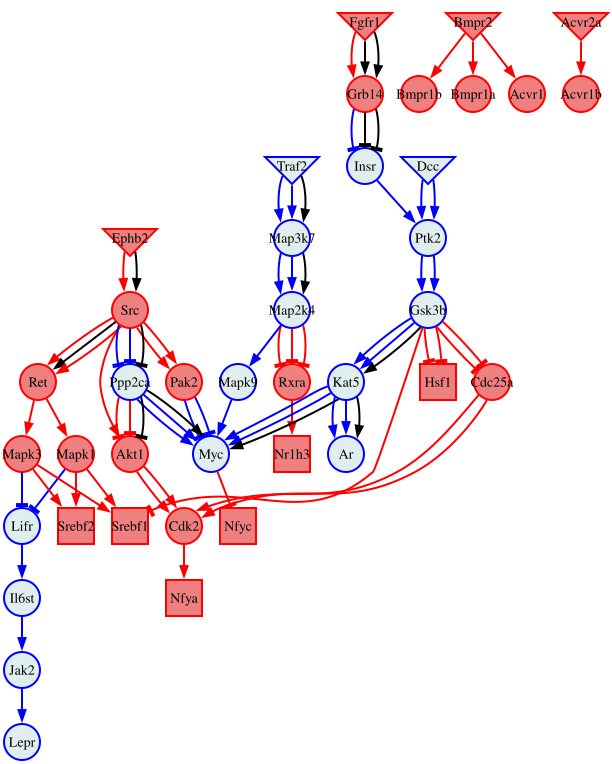

In [19]:
cn.methods.carnival.visualize_network(df_res)

We can see that the network above, largely captures a potential regulatory cascade with inhibitory (**--|**) and stimulatory (**-->**) interactions, related to JAK-STAT signalling. The network, in this case, starts from a receptor (**triangle**), coming from the top interactions, and ends with the deregulated TFs (**square**). The remainder of the nodes (**circles**) were inferred, taking their weights into account, and were not necessarily included in the input or output nodes.

In this example, we represent the directionality of signalling such that intracellular signalling is downstream of intercellular communication events. However, in biology cellular response is an admixture of both; thus such approaches are a simplification of biological reality.

### Describe Results

Let's examine the result of the subnetwork search - it provides information about the predicted signs of nodes and edges.

In [18]:
df_res[df_res['source'] == "Src"]

,source,source_type,source_weight,source_pred_val,target,target_type,target_weight,target_pred_val,edge_type,edge_pred_val
18,Src,unmeasured,0.0,1.0,Akt1,unmeasured,0.0,1.0,1,1.0
19,Src,unmeasured,0.0,1.0,Ret,unmeasured,0.0,1.0,1,1.0
24,Src,unmeasured,0.0,1.0,Pak2,unmeasured,0.0,1.0,1,1.0
3,Src,unmeasured,0.0,1.0,Ppp2ca,unmeasured,0.0,-1.0,-1,-1.0
3,Src,unmeasured,0.0,1.0,Ppp2ca,unmeasured,0.0,-1.0,-1,-1.0
17,Src,unmeasured,0.0,1.0,Ret,unmeasured,0.0,1.0,1,1.0
5,Src,unmeasured,0.0,1.0,Ppp2ca,unmeasured,0.0,-1.0,-1,-1.0
16,Src,unmeasured,0.0,1.0,Ret,unmeasured,0.0,1.0,1,1.0
25,Src,unmeasured,0.0,1.0,Pak2,unmeasured,0.0,1.0,1,1.0


#### Nodes
- **source**: source nodes in the Protein-Protein Interaction (PPI) network. Suffixes such as "_s," "_pert_c0," and "_meas_c0" indicate specific experimental conditions or measurement types (they are there simply because of how the ILP problem is formulated, and can be ignored).
- **target**: target nodes in the PPI network, with suffixes similar to the source node.

- **source_type (unmeasured, input)**: 
  - **input**: start nodes (provided by the users, here receptors).
  - **output**: end nodes (provides by the user, here transcription factors).
  - **unmeasured**: Nodes that are neither input nor output - i.e. those that predicted by the algorithm.
- **source_weight** and **target_weight**: Inputs to the causal net method, indicating the influence of "measured" nodes within the network. Only the sign is taken into account.
- **source_pred_val (1, 0, -1)**: Regulatory state of the node:
  - **1**: Upregulated
  - **0**: No differential expression
  - **-1**: Downregulated
- **target_pred_val (1, -1)**: Regulatory state of the target node:
  - **1**: Upregulated
  - **-1**: Downregulated

#### Edges (interaction)
- **edge_type (1, -1, 0)**: Type of interaction from prior knowledge:
  - **1**: Activating interaction (e.g., A -> B)
  - **-1**: Inhibitory interaction
- **edge_pred_val (1, -1)**: Predicted effect of the interaction on the target node:
  - **1**: Upregulation
  - **-1**: Downregulation


### Installing the Gurobi Solver: A Step-by-Step Guide

While in this small example the internal scipy solver works, for larger networks we recommend using a solver such as Gurobi.

Gurobi is a powerful optimization solver used in various mathematical programming problems. Here's how you can install it:

#### 1. Download Gurobi for Your Operating System:
Visit the [Gurobi download page](https://support.gurobi.com/hc/en-us/articles/4534161999889) and select the version compatible with your OS.

#### 2. Unzip and Update Path:
After downloading, unzip the file. Locate the `/bin` folder inside the unzipped directory and add it to your system's `$PATH` variable. This step is crucial as it allows your system to recognize and run Gurobi from anywhere.

#### 3. Register for an Academic License:
If you're an academic user, you can obtain a free license. Register and request an academic license through the [Gurobi portal](https://portal.gurobi.com/). Follow the prompts to complete your registration.

#### 4. Install Gurobi Python Interface:
Open your command prompt or terminal and run:

```pip install gurobipy```

This command installs the necessary Python interface to interact with Gurobi.

#### 5. Configure the Solver:
In your code, ensure the `solver` parameter is set to `gurobi` to direct your program to use the Gurobi solver.

By following these steps, you should have Gurobi installed and ready to tackle complex optimization problems.

